In [1]:
from google.colab import files

uploaded = files.upload()

Saving ai_assistant_usage_student_life.csv to ai_assistant_usage_student_life.csv


In [18]:
# Importing Libraries
#In this step, we import the Python libraries required for data analysis, visualization, preprocessing, model training, and evaluation.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

In [3]:
# Loading the Dataset
# The dataset is loaded into a Pandas DataFrame to perform preprocessing, visualization, and machine learning tasks.

df = pd.read_csv("ai_assistant_usage_student_life.csv")
df.head()

,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
0,SESSION00001,Undergraduate,Computer Science,2024-11-03,31.20,11,Studying,2,Assignment Completed,True,1.0
1,SESSION00002,Undergraduate,Psychology,2024-08-25,13.09,6,Studying,3,Assignment Completed,True,2.0
2,SESSION00003,Undergraduate,Business,2025-01-12,19.22,5,Coding,3,Assignment Completed,True,3.3
3,SESSION00004,Undergraduate,Computer Science,2025-05-06,3.70,1,Coding,3,Assignment Completed,True,3.5
4,SESSION00005,Undergraduate,Psychology,2025-03-18,28.12,9,Writing,3,Assignment Completed,True,2.9


In [4]:
df = df.drop("SessionID", axis=1)

In [5]:
# Data Preprocessing

df.isnull().sum()
# There is no missing value in this dataset

,0
StudentLevel,0
Discipline,0
SessionDate,0
SessionLengthMin,0
TotalPrompts,0
TaskType,0
AI_AssistanceLevel,0
FinalOutcome,0
UsedAgain,0
SatisfactionRating,0


In [6]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicates: 0


In [7]:
df["SessionDate"] = pd.to_datetime(df["SessionDate"])

df["Month"] = df["SessionDate"].dt.month

df["Day"] = df["SessionDate"].dt.day

df["Weekday"] = df["SessionDate"].dt.day_name()

df.drop("SessionDate", axis=1, inplace=True)

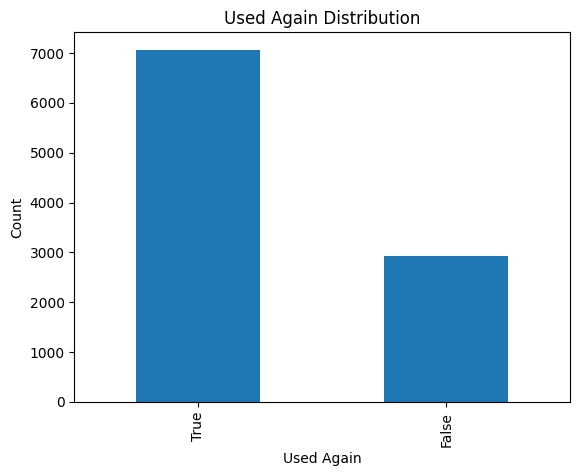

In [8]:
# Exploratory Data Analysis (EDA)
# EDA helps us understand the distribution of the data, identify patterns, and detect any anomalies before training the model.


#Graph 1

df["UsedAgain"].value_counts().plot(kind="bar")

plt.title("Used Again Distribution")

plt.xlabel("Used Again")

plt.ylabel("Count")

plt.show()

# The majority of students used the AI assistant again after their first session. This indicates a generally positive engagement with AI tools among students.

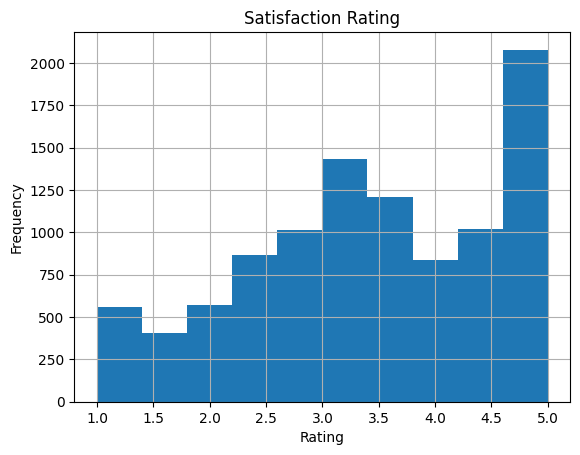

In [9]:
#Graph 2
df["SatisfactionRating"].hist()

plt.title("Satisfaction Rating")

plt.xlabel("Rating")

plt.ylabel("Frequency")

plt.show()

# Most students gave high satisfaction ratings, suggesting that the AI assistant met their learning requirements.

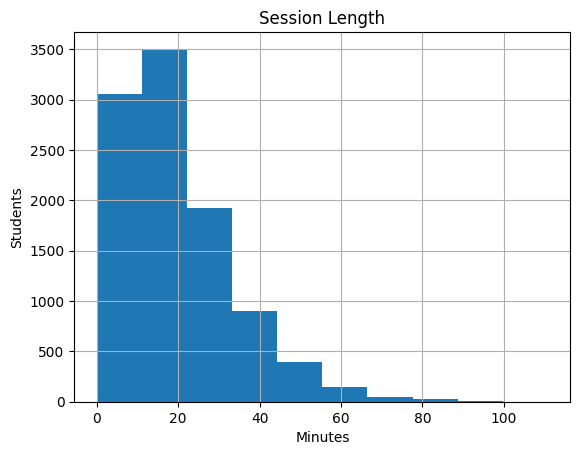

In [10]:
#Graph 3
df["SessionLengthMin"].hist()

plt.title("Session Length")

plt.xlabel("Minutes")

plt.ylabel("Students")

plt.show()

# Most AI sessions lasted between 20 and 40 minutes, indicating moderate interaction with the AI assistant.

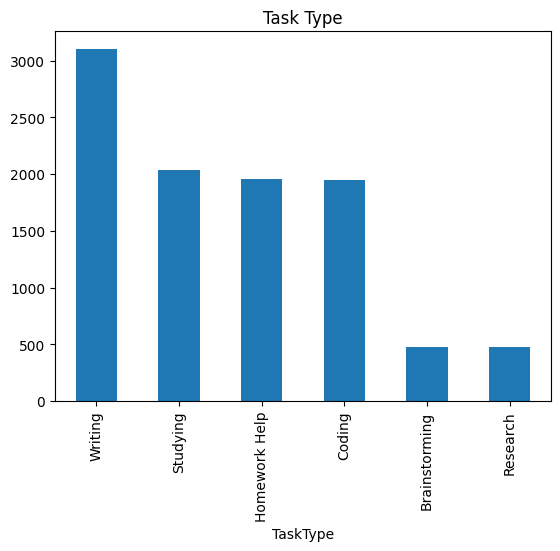

In [11]:
#Graph 4
df["TaskType"].value_counts().plot(kind="bar")

plt.title("Task Type")

plt.show()

# Coding and Homework are among the most common reasons students use AI assistants.

In [12]:
encoder = LabelEncoder()

categorical_columns = [
    "StudentLevel",
    "Discipline",
    "TaskType",
    "FinalOutcome",
    "Weekday",
    "UsedAgain"
]

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

In [13]:
X = df.drop("UsedAgain", axis=1)

y = df["UsedAgain"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [15]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.725


              precision    recall  f1-score   support

           0       0.59      0.36      0.45       615
           1       0.76      0.89      0.82      1385

    accuracy                           0.72      2000
   macro avg       0.67      0.62      0.63      2000
weighted avg       0.70      0.72      0.70      2000



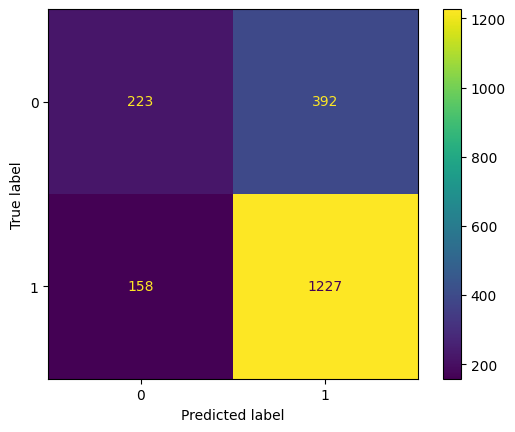

In [16]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot()

plt.show()

               Feature  Importance
2     SessionLengthMin    0.167341
6         FinalOutcome    0.136450
9                  Day    0.120111
7   SatisfactionRating    0.119046
8                Month    0.091497
3         TotalPrompts    0.084551
1           Discipline    0.072432
10             Weekday    0.071533
4             TaskType    0.054711
5   AI_AssistanceLevel    0.045560
0         StudentLevel    0.036769


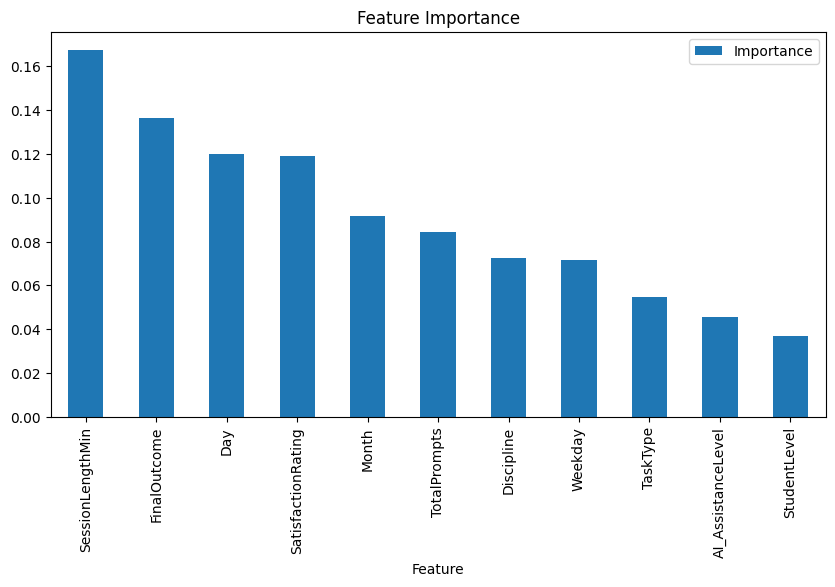

In [17]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5)
)

plt.title("Feature Importance")

plt.show()